In [3]:
!unzip sampled_images.zip

Streaming output truncated to the last 5000 lines.
  inflating: sampled_images/MH_VUN_2023-03-05-08.30-2-141.jpg  
  inflating: __MACOSX/sampled_images/._MH_VUN_2023-03-05-08.30-2-141.jpg  
  inflating: sampled_images/MH_UH_2023-02-11-03.30-2-35.jpg  
  inflating: __MACOSX/sampled_images/._MH_UH_2023-02-11-03.30-2-35.jpg  
  inflating: sampled_images/TN_Good_2023-02-23-08.30-2-101.jpg  
  inflating: __MACOSX/sampled_images/._TN_Good_2023-02-23-08.30-2-101.jpg  
  inflating: sampled_images/BIR_MOD_2023-02-13-09.30-2-23.jpg  
  inflating: __MACOSX/sampled_images/._BIR_MOD_2023-02-13-09.30-2-23.jpg  
  inflating: sampled_images/MH_UH_2023-02-18-11.00-1-9.jpg  
  inflating: __MACOSX/sampled_images/._MH_UH_2023-02-18-11.00-1-9.jpg  
  inflating: sampled_images/BENGR_Mod_2023-03-04-08.30-1-91.jpg  
  inflating: __MACOSX/sampled_images/._BENGR_Mod_2023-03-04-08.30-1-91.jpg  
  inflating: sampled_images/BIR_UNFSG_VF_2023-02-03-15.00-3-18.jpg  
  inflating: __MACOSX/sampled_images/._BIR_UNFSG_V

In [6]:
pip install torch torchvision pandas pillow numpy scikit-learn matplotlib seaborn

Using device: cuda
Classes found (6): ['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']

--- Training Basic CNN ---
Epoch 01/10 | Train Loss: 1.5093 Acc: 0.4038 | Val Loss: 1.3031 Acc: 0.4878
Epoch 02/10 | Train Loss: 1.2789 Acc: 0.4895 | Val Loss: 1.1238 Acc: 0.5667
Epoch 03/10 | Train Loss: 1.1864 Acc: 0.5250 | Val Loss: 1.1252 Acc: 0.5267
Epoch 04/10 | Train Loss: 1.1152 Acc: 0.5581 | Val Loss: 1.1245 Acc: 0.5656
Epoch 05/10 | Train Loss: 1.0709 Acc: 0.5781 | Val Loss: 0.9373 Acc: 0.6511
Epoch 06/10 | Train Loss: 1.0322 Acc: 0.5957 | Val Loss: 0.9747 Acc: 0.6078
Epoch 07/10 | Train Loss: 1.0001 Acc: 0.6060 | Val Loss: 0.8751 Acc: 0.6444
Epoch 08/10 | Train Loss: 0.9584 Acc: 0.6255 | Val Loss: 1.1205 Acc: 0.5600
Epoch 09/10 | Train Loss: 0.9384 Acc: 0.6329 | Val Loss: 0.8351 Acc: 0.6833
Epoch 10/10 | Train Loss: 0.9254 Acc: 0.6302 | Val Loss: 0.8167 Acc: 0.6578


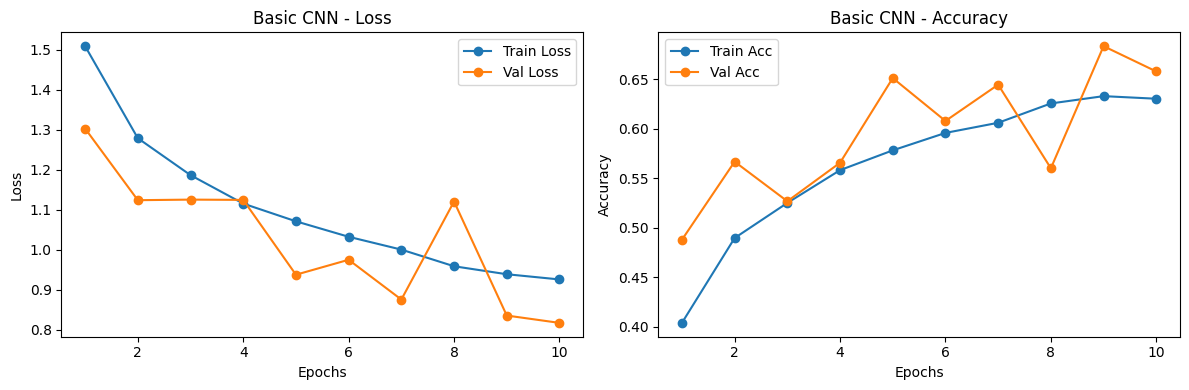


[Basic CNN] Test Metrics -> Accuracy: 0.6533, Precision: 0.6574, Recall: 0.6533, F1-Score: 0.6419


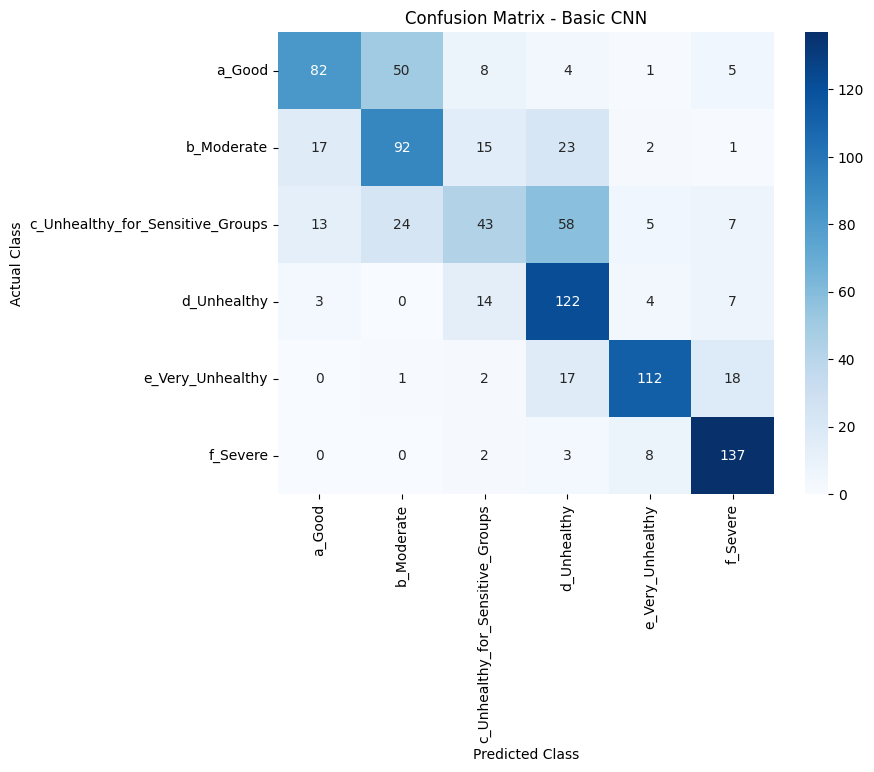

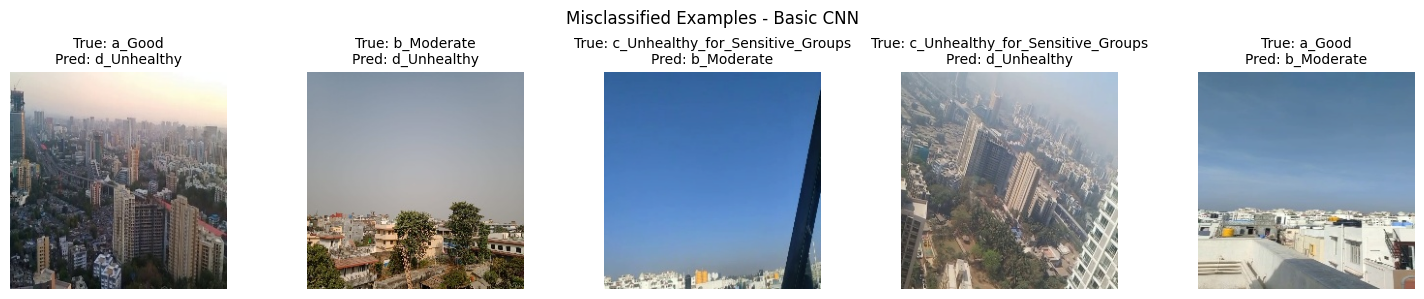

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]



--- Training ResNet18 ---
Epoch 01/10 | Train Loss: 0.6880 Acc: 0.7431 | Val Loss: 0.4276 Acc: 0.8433
Epoch 02/10 | Train Loss: 0.3020 Acc: 0.8902 | Val Loss: 0.8396 Acc: 0.8033
Epoch 03/10 | Train Loss: 0.1908 Acc: 0.9338 | Val Loss: 0.2581 Acc: 0.9044
Epoch 04/10 | Train Loss: 0.1096 Acc: 0.9621 | Val Loss: 0.6523 Acc: 0.8456
Epoch 05/10 | Train Loss: 0.1218 Acc: 0.9605 | Val Loss: 0.1449 Acc: 0.9556
Epoch 06/10 | Train Loss: 0.0963 Acc: 0.9671 | Val Loss: 0.2956 Acc: 0.8944
Epoch 07/10 | Train Loss: 0.0680 Acc: 0.9776 | Val Loss: 0.0978 Acc: 0.9678
Epoch 08/10 | Train Loss: 0.0829 Acc: 0.9695 | Val Loss: 0.1988 Acc: 0.9389
Epoch 09/10 | Train Loss: 0.0382 Acc: 0.9874 | Val Loss: 0.1155 Acc: 0.9644
Epoch 10/10 | Train Loss: 0.0277 Acc: 0.9924 | Val Loss: 0.1476 Acc: 0.9611
>> Early stopping triggered! Restoring best weights.


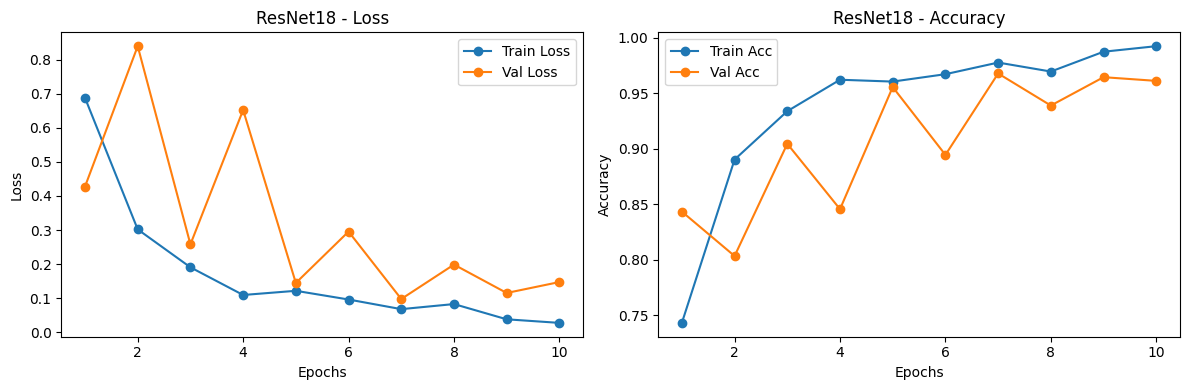


[ResNet18] Test Metrics -> Accuracy: 0.9644, Precision: 0.9648, Recall: 0.9644, F1-Score: 0.9645


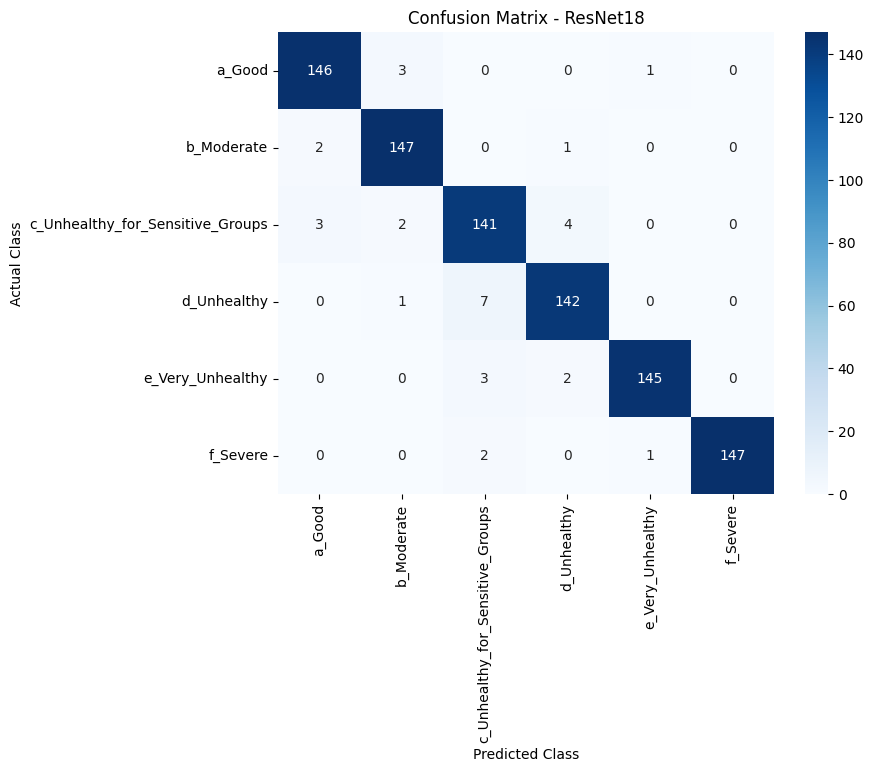

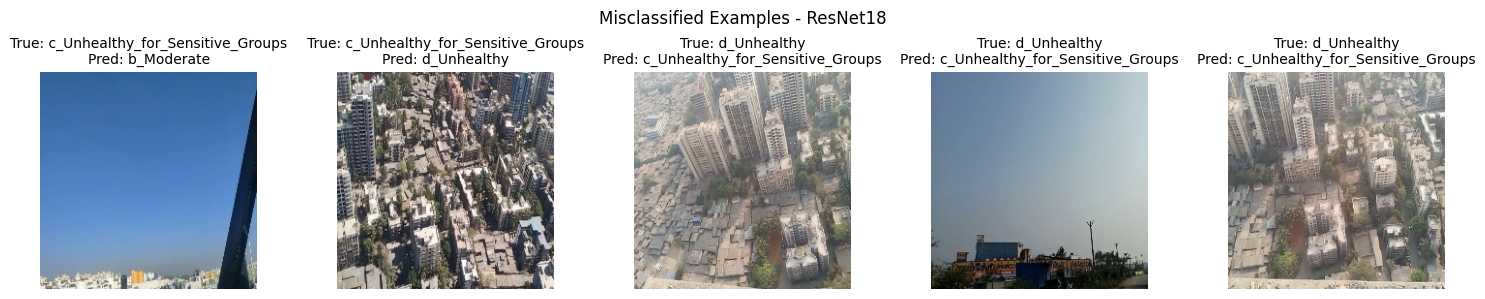

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
import pandas as pd
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# HYPERPARAMETERS & CONFIG
class Config:
    CSV_PATH = 'data.csv'
    IMAGE_DIR = 'sampled_images'
    IMG_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 10
    LEARNING_RATE = 1e-3
    PATIENCE = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SEED = 42

torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)

# TASK 1: DATA PREPARATION
class AQIDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

        # Map string labels to integers based on AQI_Class
        self.classes = sorted(df['AQI_Class'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.img_dir, row['Filename'])

        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[row['AQI_Class']]

        if self.transform:
            image = self.transform(image)

        return image, label

def get_dataloaders(csv_path, img_dir):
    df = pd.read_csv(csv_path)

    # Clean headers just in case of hidden whitespaces
    df.columns = df.columns.str.strip()

    # 70/15/15 Split
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=Config.SEED, stratify=df['AQI_Class'])
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=Config.SEED, stratify=temp_df['AQI_Class'])

    # Transforms: Resize to 224x224 and Normalize using ImageNet standards
    base_transform = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = AQIDataset(train_df, img_dir, transform=base_transform)
    val_dataset = AQIDataset(val_df, img_dir, transform=base_transform)
    test_dataset = AQIDataset(test_df, img_dir, transform=base_transform)

    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader, train_dataset.classes

class EarlyStopping:
    def __init__(self, patience=3, delta=0):
        self.patience = patience
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.delta = delta

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            # Save best model weights
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# TASK 2: BASIC CNN FROM SCRATCH
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# TASK 3: PRETRAINED MODEL (TRANSFER LEARNING)
def get_pretrained_resnet(num_classes):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

    # Freeze the initial layers (~10 layers frozen to save time & compute)
    # ResNet18 blocks: conv1, bn1, layer1, layer2, layer3, layer4
    frozen_modules = [model.conv1, model.bn1, model.layer1, model.layer2]
    for module in frozen_modules:
        for param in module.parameters():
            param.requires_grad = False

    # Replace final classification layer for our specific number of classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

# TRAINING & EVALUATION LOOP
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, name):
    print(f"\n--- Training {name} ---")
    model.to(Config.DEVICE)
    early_stopping = EarlyStopping(patience=Config.PATIENCE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(">> Early stopping triggered! Restoring best weights.")
            break

    # Load best weights before returning
    model.load_state_dict(torch.load('best_model.pth'))
    return model, history

# TASK 4 & 6: EVALUATION & MISCLASSIFICATIONS
def evaluate_and_analyze(model, test_loader, classes, name):
    model.eval()
    all_preds, all_labels = [], []
    misclassified_imgs, mis_preds, mis_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Catch misclassified images for Task 6
            mis_mask = preds != labels
            if mis_mask.any() and len(misclassified_imgs) < 10:
                mis_imgs = inputs[mis_mask].cpu()
                m_preds = preds[mis_mask].cpu()
                m_labels = labels[mis_mask].cpu()

                for i in range(len(mis_imgs)):
                    if len(misclassified_imgs) < 10:
                        misclassified_imgs.append(mis_imgs[i])
                        mis_preds.append(classes[m_preds[i]])
                        mis_labels.append(classes[m_labels[i]])

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    print(f"\n[{name}] Test Metrics -> Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

    # Task 6: Visualize Misclassifications
    if misclassified_imgs:
        num_imgs = min(5, len(misclassified_imgs)) # Plot up to 5 misclassifications
        fig, axes = plt.subplots(1, num_imgs, figsize=(15, 3))

        # Ensure axes is iterable even if there is only 1 misclassification
        if num_imgs == 1: axes = [axes]

        for idx, ax in enumerate(axes):
            # Unnormalize the image back to viewable RGB
            img = misclassified_imgs[idx].numpy().transpose((1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            ax.imshow(img)
            ax.set_title(f"True: {mis_labels[idx]}\nPred: {mis_preds[idx]}", fontsize=10)
            ax.axis('off')
        plt.suptitle(f"Misclassified Examples - {name}")
        plt.tight_layout()
        plt.show()

# TASK 5: PLOTTING TRAINING CURVES
def plot_curves(history, name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    ax1.set_title(f'{name} - Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, history['train_acc'], label='Train Acc', marker='o')
    ax2.plot(epochs, history['val_acc'], label='Val Acc', marker='o')
    ax2.set_title(f'{name} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# MAIN EXECUTION SCRIPT
if __name__ == '__main__':
    print(f"Using device: {Config.DEVICE}")

    # Initialize Loaders
    train_loader, val_loader, test_loader, classes = get_dataloaders(Config.CSV_PATH, Config.IMAGE_DIR)
    num_classes = len(classes)
    print(f"Classes found ({num_classes}): {classes}")

    criterion = nn.CrossEntropyLoss()

    # 1. Train Basic CNN
    basic_cnn = BasicCNN(num_classes)
    optimizer_cnn = optim.Adam(basic_cnn.parameters(), lr=Config.LEARNING_RATE)
    basic_cnn, hist_cnn = train_model(basic_cnn, train_loader, val_loader, criterion, optimizer_cnn, Config.EPOCHS, "Basic CNN")
    plot_curves(hist_cnn, "Basic CNN")
    evaluate_and_analyze(basic_cnn, test_loader, classes, "Basic CNN")

    # 2. Train ResNet18 (Transfer Learning)
    resnet_model = get_pretrained_resnet(num_classes)

    # Only optimize parameters that require gradients (the unfrozen deeper layers)
    optimizer_res = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=Config.LEARNING_RATE)
    resnet_model, hist_res = train_model(resnet_model, train_loader, val_loader, criterion, optimizer_res, Config.EPOCHS, "ResNet18")
    plot_curves(hist_res, "ResNet18")
    evaluate_and_analyze(resnet_model, test_loader, classes, "ResNet18")